#### Use inset_axes() to pin multiple histograms on a map.
- Use Cartopy to plot the map.
- Define locations (latitude, longitude) to pin the histograms.
- Create individual histograms at each location.
- median and percentile ranges for projected percentage changes in TC frequency, category 4–5 TC frequency
    - For TC frequency, the 5th–95th-percentile range across published estimates is shown.
    - For category 4–5, TC frequency, TC intensity, and TC near-storm rain rates the 10th–90th-percentile range is shown.
- Overlay the histograms on the map using - ax.inset_axes() or OffsetImage from mpl_toolkits.axes_grid1

Ming Ge April 2025

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

import tc_helping
from importlib import reload
reload(tc_helping)
from tc_helping import rd_HR_SH

In [5]:
# plot 6 custom boxplots in a single figure 
def box_custom_1_inset(ax, data1, q1, q3, title_s):
    '''
    q1: two Q1 correspondent to data1,  
    q3: two Q3 correspondent to data1 
    '''
    # Compute custom statistics for data1 (with whiskers equal to Q1 and Q3)
    q1_1 = np.percentile(data1, q1[0])
    q3_1 = np.percentile(data1, q3[0])
    med1 = np.median(data1)
    box1 = {
        'med': med1,
        'q1': q1_1,
        'q3': q3_1,
        'whislo': q1_1,  # lower whisker set to Q1
        'whishi': q3_1,  # upper whisker set to Q3
        'fliers': []     # no outliers
    }

    #  Use patch_artist=True so that boxes are drawn as Patch objects
    ax.bxp([box1], patch_artist=True,
       boxprops={'facecolor': 'grey', 'alpha':0.5}, 
                 #'color': 'lightsteelblue'},
       #whiskerprops={'color': 'grey'},
       #capprops={'color': 'grey'},
       medianprops={'color': 'black'})

    # Add a horizontal line at y=0
    ax.axhline(y=0, color='grey', linestyle='--', linewidth=1)
    # Set the font size of the y-axis tick labels
    ax.tick_params(axis='y', labelsize=6, pad=0)  # Adjust 'labelsize' as needed

    ax.set_xticklabels(["intensity"], fontsize=5)
    #ax.set_yticklabels(fontsize=8)
    ax.set_title(title_s)
    ax.set_ylabel("% Change", labelpad=0, fontsize=8)

In [11]:
# plot 6 custom boxplots in a single figure 
def box_custom_2_inset(ax, data1, data2, q1, q3, title_s):
    '''
    q1: two Q1 correspondent to data1, data2
    q3: two Q3 correspondent to data1, data2
    '''
    # Compute custom statistics for data1 (with whiskers equal to Q1 and Q3)
    q1_1 = np.percentile(data1, q1[0])
    q3_1 = np.percentile(data1, q3[0])
    med1 = np.median(data1)
    box1 = {
        'med': med1,
        'q1': q1_1,
        'q3': q3_1,
        'whislo': q1_1,  # lower whisker set to Q1
        'whishi': q3_1,  # upper whisker set to Q3
        'fliers': []     # no outliers
    }

    # Compute custom statistics for data2
    q1_2 = np.percentile(data2, q1[1])
    q3_2 = np.percentile(data2, q3[1])
    med2 = np.median(data2)
    box2 = {
        'med': med2,
        'q1': q1_2,
        'q3': q3_2,
        'whislo': q1_2,  # lower whisker set to Q1
        'whishi': q3_2,  # upper whisker set to Q3
        'fliers': []     # no outliers
    }

    #  Use patch_artist=True so that boxes are drawn as Patch objects
    ax.bxp([box1, box2], patch_artist=True,
       boxprops={'facecolor': 'grey', 'alpha':0.5}, 
                 #'color': 'lightsteelblue'},
       #whiskerprops={'color': 'grey'},
       #capprops={'color': 'grey'},
       medianprops={'color': 'black'})

    # Add a horizontal line at y=0
    ax.axhline(y=0, color='grey', linestyle='--', linewidth=1)
    # Set the font size of the y-axis tick labels
    ax.tick_params(axis='y', labelsize=6, pad=0)  # Adjust 'labelsize' as needed
    #ax.set_ylim(-300, 100)
    ax.set_xticklabels(["TC Freq", "Cat 3-5"], fontsize=5)
    #ax.set_yticklabels(fontsize=8)
    ax.set_title(title_s)
    ax.set_ylabel("% Change", labelpad=0, fontsize=8)

In [17]:
import matplotlib.cm as cm
import glob
import pandas as pd
from matplotlib.colors import BoundaryNorm, ListedColormap
SAFFIR_SIM_CAT = [34, 64, 83, 96, 113, 137, 1000]
norm = BoundaryNorm([0] + SAFFIR_SIM_CAT, len(SAFFIR_SIM_CAT))
CAT_COLORS = cm.hot_r(np.linspace(0, 1, len(SAFFIR_SIM_CAT)))
CAT_NAMES = {
    -1: 'TD',
    0: 'TS',
    1: 'HU1',
    2: 'HU2',
    3: 'HU3',
    4: 'HU4',
    5: 'HU5'}
Australian_CAT = [38, 55, 74, 97, 120, 1000]
def rd_HR_SH(dir_hr, year_s, year_e, proj, lon_cen, extent, is_plotting, cmap='cmap', cat_color=CAT_COLORS, cat_name = CAT_NAMES, is_GreaterCat3=False):
    #cmap = new_cmap_australia
    #cat_color = CAT_COLORS_australia
    #cat_name = CAT_australia

    kt2ms = 0.514444
    lon_s = extent[0]
    lon_e = extent[1]
    lat_s = extent[2]
    lat_e = extent[3]
    n_year = year_e - year_s + 1

    dirs = [ff for ff in glob.glob(dir_hr + "*")]
    n_mem = len(dirs)

    tc_count = np.zeros((n_year, 2))
    vmax_1d  = np.zeros((n_year, 2)) ; vmax_1d[:] = np.nan
    lat_vmax = np.zeros((n_year, 2)) ; lat_vmax[:] = np.nan
    data_4d  = np.zeros((n_mem, n_year, 3, 2)); data_4d[:] = np.nan

    nm = 0
     
    for dir in dirs:
         
        tc_count[:] = 0
        for year in range(year_s-1, year_e + 1):
            name = dir[len(dir_hr) + 8:-4]
            flnm = dir + '/' + 'CESM_HR_TC_'+ name+'_output_' + str(year) + '_SH.txt'
            df_tc = pd.read_csv(flnm, delimiter=', ', engine='python')
            if year == year_s-1:
                df = df_tc.loc[(df_tc['year'].astype(int) == year_s-1) &
                               (df_tc['month'].astype(int) == 12)]

            elif year == year_e:
                df = df_tc.loc[df_tc['year'].astype(int) == year_e &
                               ((df_tc['month'].astype(int) >= 1) &
                                (df_tc['month'].astype(int) <= 4))]
            else:
                df = df_tc.loc[(df_tc['year'].astype(int) == year) &
                               (((df_tc['month'].astype(int) >= 1) &
                                 (df_tc['month'].astype(int) <= 4)) |
                                (df_tc['month'].astype(int) == 12))]

            tc_ids = np.unique(df.track_id.astype(int))
            for tc_id in tc_ids:
                df_single = df.loc[df.track_id.astype(int) == tc_id]

                lat_1d = df_single.lat.values.astype(float)
                lon_1d = df_single.lon.values.astype(float)
                spd_1d = df_single.wind10.values.astype(float)/kt2ms

                lon_1d = np.where(lon_1d < 0, lon_1d+360, lon_1d)

                latmask = np.where((lat_1d>lat_s) & (lat_1d < lat_e))

                if(len(latmask[0]) !=0):
                    lat_latmask = lat_1d[latmask]
                    lon_latmask = lon_1d[latmask]
                    spd_latmask = spd_1d[latmask]

                    lonmask = np.where((lon_latmask>lon_s) & (lon_latmask < lon_e))
                    if(len(lonmask[0]) !=0):
                        lat_final = lat_latmask[lonmask]
                        lon_final = lon_latmask[lonmask]
                        spd_final = spd_latmask[lonmask]

                        # find location of Vmax
                        argmax_ind = np.argmax(spd_final)
                        vmax_annual = np.max(spd_final)
                        if  is_GreaterCat3 == False:
                            vmax_1d [year-year_s] = vmax_annual
                            lat_vmax[year-year_s] = lat_final[argmax_ind]
                            tc_count[year-year_s] += 1
                        else:
                            if vmax_annual >= Australian_CAT[0]:
                                vmax_1d [year-year_s,0] = vmax_annual
                                lat_vmax[year-year_s,0] = lat_final[argmax_ind]
                                tc_count[year-year_s,0] += 1
                            # we only care wind > cat 3 Australia scale
                            if vmax_annual >= Australian_CAT[2]:
                                vmax_1d [year-year_s,1] = vmax_annual
                                lat_vmax[year-year_s,1] = lat_final[argmax_ind]
                                tc_count[year-year_s,1] += 1
            #print(nm)
            #print(vmax_1d[:,0])
            #print(vmax_1d[:,1])
            #print(tc_count)                    
        data_4d[nm, :,  0, :] = tc_count
        data_4d[nm, :,  1, :] = vmax_1d
        data_4d[nm, :,  2, :] = lat_vmax
        #print(tc_count.max())
        #print(vmax_1d.max,' values',  vmax_1d)
        nm = nm + 1
    return data_4d 
    
#data_HR_BCR1 = rd_HR_SH(dir_hr, year_s, year_e, proj, lon_cen, extent, False, 
#                            cmap='new_cmap_australia', cat_color = 'CAT_COLORS_australia', 
#                        cat_name='CAT_australia', is_GreaterCat3=True)

In [24]:
# plot 6 custom boxplots in a single figure 
def box_custom_3_inset(ax, data1, data2,  data3, q1, q3, title_s):
    '''
    q1: two Q1 correspondent to data1, data2
    q3: two Q3 correspondent to data1, data2
    '''
    # Compute custom statistics for data1 (with whiskers equal to Q1 and Q3)
    q1_1 = np.percentile(data1, q1[0])
    q3_1 = np.percentile(data1, q3[0])
    med1 = np.median(data1)
    box1 = {
        'med': med1,
        'q1': q1_1,
        'q3': q3_1,
        'whislo': q1_1,  # lower whisker set to Q1
        'whishi': q3_1,  # upper whisker set to Q3
        'fliers': []     # no outliers
    }

    # Compute custom statistics for data2
    q1_2 = np.percentile(data2, q1[1])
    q3_2 = np.percentile(data2, q3[1])
    med2 = np.median(data2)
    box2 = {
        'med': med2,
        'q1': q1_2,
        'q3': q3_2,
        'whislo': q1_2,  # lower whisker set to Q1
        'whishi': q3_2,  # upper whisker set to Q3
        'fliers': []     # no outliers
    }

    # Compute custom statistics for data3
    q1_2 = np.percentile(data3, q1[2])
    q3_2 = np.percentile(data3, q3[2])
    med2 = np.median(data3)
    box3 = {
        'med': med2,
        'q1': q1_2,
        'q3': q3_2,
        'whislo': q1_2,  # lower whisker set to Q1
        'whishi': q3_2,  # upper whisker set to Q3
        'fliers': []     # no outliers
    }

    #  Use patch_artist=True so that boxes are drawn as Patch objects
    ax.bxp([box1, box2, box3], patch_artist=True,
       boxprops={'facecolor': 'grey', 'alpha':0.5}, 
                 #'color': 'lightsteelblue'},
       #whiskerprops={'color': 'grey'},
       #capprops={'color': 'grey'},
       medianprops={'color': 'black'})

    # Add a horizontal line at y=0
    ax.axhline(y=0, color='grey', linestyle='--', linewidth=1)
    # Set the font size of the y-axis tick labels
    ax.tick_params(axis='y', labelsize=6, pad=0)  # Adjust 'labelsize' as needed
    ax.set_ylim(-10, 10) 
    ax.set_xticklabels(["TC Freq", "Cat 3-5", "intensity"], fontsize=5)
    #ax.set_yticklabels(fontsize=8)
    ax.set_title(title_s)
    ax.set_ylabel("% Change", labelpad=0, fontsize=8)

In [19]:
dir_plot = '/glade/campaign/mmm/c3we/mingge/TC/PLOT/'
dir_hr   = '/glade/campaign/mmm/c3we/done/pcast/CESM_HR/'
dir_o    = '/glade/campaign/mmm/c3we/mingge/TC/DATA/'

#  time period
year_s = 1940
year_e = 2100

n_year = year_e - year_s + 1

# 5 Buckley Cyclone Regions and New Zealand
region_s = ['BC 1', 'BC 2', 'BC 3', 'BC 4', 'BC 5', 'New Zealand']
lat_s_1d = [-40, -27, -20, -25, -40, -48]
lat_e_1d = [-27, -9,  -9,  -9, -22, -30]
lon_s_1d = [145, 143, 132, 100, 100, 163]
lon_e_1d = [160, 158, 143, 132, 145, 183] 
n_region = len(lat_s_1d)

n_mem = 10

In [20]:
%%time

slope_4d = np.zeros((2, n_region, n_mem, 2))
xx = np.array(range(year_s, year_e+1))
slope2percentage = 100 #n_year

for nr in range(n_region): 
    #for nr in range(3,4): 
    if nr == n_region - 1:
        print(' New Zealand ' )
    else:
        print(' Australia Buckley Cyclone Region ' + str(nr + 1))
        
    lat_s = lat_s_1d[nr]
    lat_e = lat_e_1d[nr]
    lon_s = lon_s_1d[nr]
    lon_e = lon_e_1d[nr]
    lon_cen = (lon_s+lon_e)*0.5
    proj   = ccrs.PlateCarree(central_longitude=lon_cen)
    extent = [lon_s, lon_e, lat_s, lat_e]
    
    time_s = str(year_s) + '-' + str(year_e)
    data_HR_BCR1 = rd_HR_SH(dir_hr, year_s, year_e, proj, lon_cen, extent, False, cmap='new_cmap_australia', cat_color = 'CAT_COLORS_australia', cat_name='CAT_australia', is_GreaterCat3=True)
    # we use tc_count [ n_mem, n_year, 0 , :]   
    #print(data_HR_BCR1.shape) # (n_mem, n_year, n_var, cat)
    # TC frequency (n_mem, n_year, [cat0, cat3-5])
    data_fre =  data_HR_BCR1[:,:,0,:] #((10, 161, 2))
    data_spd =  data_HR_BCR1[:,:,1,:] 
     
    for nm in range(n_mem):
        for nv in range(2):
            slope_4d[0, nr, nm, nv] = np.polyfit(xx, data_fre[nm,:,nv], 1)[0]
            idx = ~np.isnan(data_spd[nm,:,nv])
            #print(type(idx))
            slope_4d[1, nr, nm, nv] = np.polyfit(xx[idx], data_spd[nm,:,nv][idx], 1)[0] 
slope_4d = slope_4d*slope2percentage

 Australia Buckley Cyclone Region 1
 Australia Buckley Cyclone Region 2
 Australia Buckley Cyclone Region 3
 Australia Buckley Cyclone Region 4
 Australia Buckley Cyclone Region 5
 New Zealand 
CPU times: user 1min 55s, sys: 1.1 s, total: 1min 56s
Wall time: 2min 24s


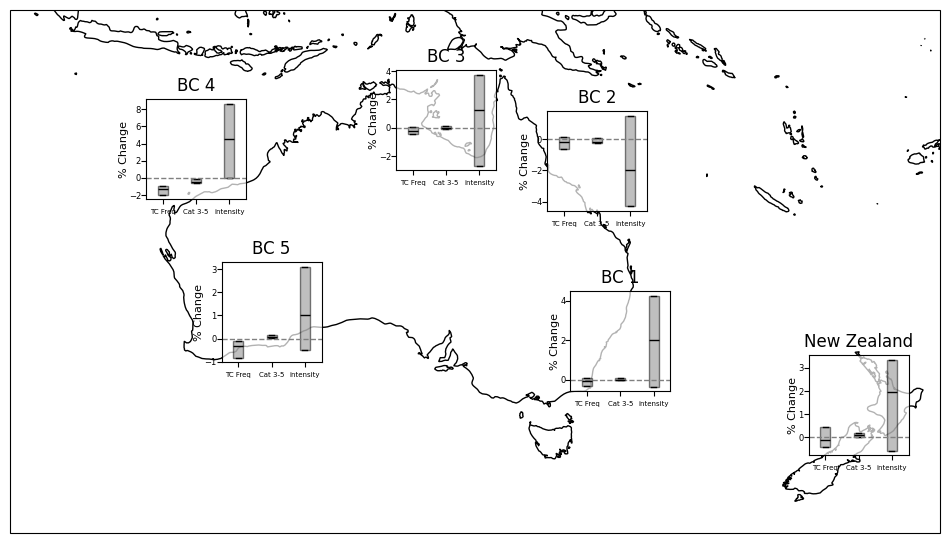

In [21]:
# Map locations (latitude, longitude)
#locations = [(40, -105), (35, -100), (42, -95)]  # (lat, lon)
latc_1d = ((np.array(lat_s_1d) + np.array(lat_e_1d))/2).tolist()
lonc_1d = ((np.array(lon_s_1d) + np.array(lon_e_1d))/2).tolist()

locations = list(zip(latc_1d, lonc_1d))

# Plot the map
fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={'projection': ccrs.PlateCarree()})
ax.set_extent([100, 180, -50, -5], crs=ccrs.PlateCarree())

# Add map features
#ax.stock_img()
ax.coastlines()
#ax.gridlines(draw_labels=True)

# Plot histograms at different locations
for nr in range(n_region): 
    lat, lon = locations[nr]
    # Create an inset axes for each histogram
    inset_ax = inset_axes(ax, width=1, height=1.0, 
                          loc='center',
                          # Use absolute positioning
                          bbox_to_anchor=(lon, lat, 0, 0),
                          bbox_transform=ax.transData, borderpad=0)
    # Set axes background to some transparent
    inset_ax.patch.set_alpha(0.7)
    
    data_1 = slope_4d[0, nr, :, 0]
    data_2 = slope_4d[0, nr, :, 1]
    data_3 = slope_4d[1, nr, :, 0]
    #print(data_3)

    # Plotting:
    # data_1: TC frequency 5%-95%,
    # data_2: Cat 4-5 frequency: 10%-90%
    # data_3: Cat 4-5 frequency: 10%-90%
    #box_custom_1_inset(inset_ax, data_3,  [10], [90], region_s[nr])
    box_custom_3_inset(inset_ax, data_1, data_2, data_3, [5,10,10], [95,90,90], region_s[nr])
    #box_custom_2_inset(inset_ax, data_1, data_2, [5,10], [95,90], region_s[nr])
#plt.title("boxplots Pinned on Different Regions of the Map")


#### Same set_ylim

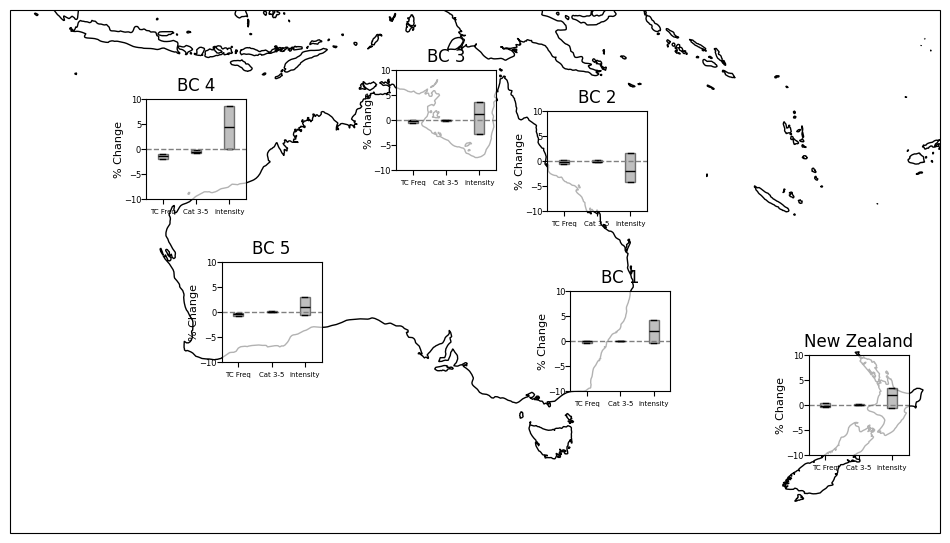

In [25]:
# Map locations (latitude, longitude)
#locations = [(40, -105), (35, -100), (42, -95)]  # (lat, lon)
latc_1d = ((np.array(lat_s_1d) + np.array(lat_e_1d))/2).tolist()
lonc_1d = ((np.array(lon_s_1d) + np.array(lon_e_1d))/2).tolist()

locations = list(zip(latc_1d, lonc_1d))

# Plot the map
fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={'projection': ccrs.PlateCarree()})
ax.set_extent([100, 180, -50, -5], crs=ccrs.PlateCarree())

# Add map features
#ax.stock_img()
ax.coastlines()
#ax.gridlines(draw_labels=True)

# Plot histograms at different locations
for nr in range(n_region): 
    lat, lon = locations[nr]
    # Create an inset axes for each histogram
    inset_ax = inset_axes(ax, width=1, height=1.0, 
                          loc='center',
                          # Use absolute positioning
                          bbox_to_anchor=(lon, lat, 0, 0),
                          bbox_transform=ax.transData, borderpad=0)
    # Set axes background to some transparent
    inset_ax.patch.set_alpha(0.7)
    
    data_1 = slope_4d[0, nr, :, 0]
    data_2 = slope_4d[0, nr, :, 1]
    data_3 = slope_4d[1, nr, :, 0]
    #print(data_3)

    # Plotting:
    # data_1: TC frequency 5%-95%,
    # data_2: Cat 4-5 frequency: 10%-90%
    # data_3: Cat 4-5 frequency: 10%-90%
    #box_custom_1_inset(inset_ax, data_3,  [10], [90], region_s[nr])
    box_custom_3_inset(inset_ax, data_1, data_2, data_3, [5,10,10], [95,90,90], region_s[nr])
    #box_custom_2_inset(inset_ax, data_1, data_2, [5,10], [95,90], region_s[nr])
#plt.title("boxplots Pinned on Different Regions of the Map")
